In [2]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [1]:
male = pd.read_excel("../data/female_data.xlsx")
female = pd.read_excel("../data/male_data.xlsx")
male.head()

NameError: name 'pd' is not defined

In [11]:
pengalaman = '^(F|P|PE|PSI|TSM)'
kolom_pengalaman = male.filter(regex=pengalaman)
male["pengalaman_ms"] = round(kolom_pengalaman.mean(axis=1))
male.head()

,Kode Sampel,Jenis Kelamin,F1,F2,F3,P1,P2,P3,P4,P5,...,DS2,DS3,DS4,HKI1,HKI2,HKI3,HKI4,pengalaman_mengalami,sumber_informasi_dan_dukungan_sosial,pengalaman_ms
0,PH76,Male,4,1,4,2,4,2,3,4,...,3,1,3,2,4,3,1,2.684211,2.111111,3.0
1,PH78,Male,3,3,2,2,3,3,4,3,...,2,2,3,1,4,2,3,2.631579,2.333333,3.0
2,PH79,Male,1,4,1,2,2,3,2,3,...,2,2,3,1,4,2,3,2.368421,2.333333,2.0
3,PH714,Male,3,2,3,3,3,3,4,3,...,2,2,3,4,4,2,3,3.000000,2.333333,3.0
4,PH717,Male,4,1,4,4,4,4,4,4,...,4,4,4,4,1,4,4,3.315789,3.444444,3.0


In [14]:
hk = male.filter(like='HKI')
male['sumber_informasi'] = round(hk.mean(axis=1))
male.head()

,Kode Sampel,Jenis Kelamin,F1,F2,F3,P1,P2,P3,P4,P5,...,DS3,DS4,HKI1,HKI2,HKI3,HKI4,pengalaman_mengalami,sumber_informasi_dan_dukungan_sosial,pengalaman_ms,sumber_informasi
0,PH76,Male,4,1,4,2,4,2,3,4,...,1,3,2,4,3,1,2.684211,2.111111,3.0,2.0
1,PH78,Male,3,3,2,2,3,3,4,3,...,2,3,1,4,2,3,2.631579,2.333333,3.0,2.0
2,PH79,Male,1,4,1,2,2,3,2,3,...,2,3,1,4,2,3,2.368421,2.333333,2.0,2.0
3,PH714,Male,3,2,3,3,3,3,4,3,...,2,3,4,4,2,3,3.000000,2.333333,3.0,3.0
4,PH717,Male,4,1,4,4,4,4,4,4,...,4,4,4,1,4,4,3.315789,3.444444,3.0,3.0


In [15]:
ds = male.filter(like="DS")
male['dukungan_sosial'] = round(ds.mean(axis=1))
male.head()

,Kode Sampel,Jenis Kelamin,F1,F2,F3,P1,P2,P3,P4,P5,...,DS4,HKI1,HKI2,HKI3,HKI4,pengalaman_mengalami,sumber_informasi_dan_dukungan_sosial,pengalaman_ms,sumber_informasi,dukungan_sosial
0,PH76,Male,4,1,4,2,4,2,3,4,...,3,2,4,3,1,2.684211,2.111111,3.0,2.0,2.0
1,PH78,Male,3,3,2,2,3,3,4,3,...,3,1,4,2,3,2.631579,2.333333,3.0,2.0,2.0
2,PH79,Male,1,4,1,2,2,3,2,3,...,3,1,4,2,3,2.368421,2.333333,2.0,2.0,2.0
3,PH714,Male,3,2,3,3,3,3,4,3,...,3,4,4,2,3,3.000000,2.333333,3.0,3.0,2.0
4,PH717,Male,4,1,4,4,4,4,4,4,...,4,4,1,4,4,3.315789,3.444444,3.0,3.0,4.0


In [17]:
male_ekspor = male[["pengalaman_ms", "sumber_informasi", "dukungan_sosial"]]
male_ekspor.to_excel("male.xlsx", index=False)

In [40]:
# Membuat tabel kontingensi
# ganti 'df' dengan nama variabel DataFrame milikmu
tabel_dukungan = pd.crosstab(male_ekspor['dukungan_sosial'], 
                             male_ekspor['pengalaman_ms'], 
                             margins=True) # Menambahkan total baris & kolom

print("Tabel Kontingensi: Dukungan Sosial vs Pengalaman Menarche")
print(tabel_dukungan)

Tabel Kontingensi: Dukungan Sosial vs Pengalaman Menarche
pengalaman_ms    2.0  3.0  4.0  All
dukungan_sosial                    
1.0                3    3    0    6
2.0              119  346    0  465
3.0               36  198    2  236
4.0                0   27    2   29
All              158  574    4  736


In [41]:
# Membuat tabel kontingensi
# ganti 'df' dengan nama variabel DataFrame milikmu
tabel_sumber = pd.crosstab(male_ekspor['sumber_informasi'], 
                             male_ekspor['pengalaman_ms'], 
                             margins=True) # Menambahkan total baris & kolom

print("Tabel Kontingensi: Dukungan Sosial vs Pengalaman Menarche")
print(tabel_sumber)

Tabel Kontingensi: Dukungan Sosial vs Pengalaman Menarche
pengalaman_ms     2.0  3.0  4.0  All
sumber_informasi                    
2.0                80  215    0  295
3.0                72  322    3  397
4.0                 6   37    1   44
All               158  574    4  736


In [42]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# 1. Recoding Variabel Dependen (Pengalaman Menarche)
# 2.0 -> 0 (Buruk), 3.0 & 4.0 -> 1 (Baik)
male_ekspor['pengalaman_biner'] = male_ekspor['pengalaman_ms'].replace({2.0: 0, 3.0: 1, 4.0: 1})

# 2. Recoding Variabel Independen (Dukungan Sosial)
# 1.0 & 2.0 -> 0 (Kurang), 3.0 & 4.0 -> 1 (Baik)
male_ekspor['dukungan_biner'] = male_ekspor['dukungan_sosial'].replace({1.0: 0, 2.0: 0, 3.0: 1, 4.0: 1})

# 3. Recoding Variabel Independen (Sumber Informasi)
# 2.0 -> 0 (Kurang), 3.0 & 4.0 -> 1 (Baik)
male_ekspor['sumber_biner'] = male_ekspor['sumber_informasi'].replace({2.0: 0, 3.0: 1, 4.0: 1})

/tmp/ipykernel_41419/1640503398.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_ekspor['pengalaman_biner'] = male_ekspor['pengalaman_ms'].replace({2.0: 0, 3.0: 1, 4.0: 1})
/tmp/ipykernel_41419/1640503398.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_ekspor['dukungan_biner'] = male_ekspor['dukungan_sosial'].replace({1.0: 0, 2.0: 0, 3.0: 1, 4.0: 1})
/tmp/ipykernel_41419/1640503398.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [43]:
male_ekspor

,pengalaman_ms,sumber_informasi,dukungan_sosial,pengalaman_biner,dukungan_biner,sumber_biner
0,3.0,2.0,2.0,1.0,0.0,0.0
1,3.0,2.0,2.0,1.0,0.0,0.0
2,2.0,2.0,2.0,0.0,0.0,0.0
3,3.0,3.0,2.0,1.0,0.0,1.0
4,3.0,3.0,4.0,1.0,1.0,1.0
...,...,...,...,...,...,...
731,2.0,3.0,2.0,0.0,0.0,1.0
732,3.0,3.0,2.0,1.0,0.0,1.0
733,3.0,4.0,3.0,1.0,1.0,1.0
734,2.0,3.0,2.0,0.0,0.0,1.0


In [44]:
male_ekspor.to_excel("male_final.xlsx", index=False)

In [45]:
# Membuat model logistik
# Formula: 'dependen ~ independen1 + independen2'
model = smf.logit('pengalaman_biner ~ dukungan_biner + sumber_biner', data=male_ekspor).fit()

# Menampilkan ringkasan hasil
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.504582
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       pengalaman_biner   No. Observations:                  736
Model:                          Logit   Df Residuals:                      733
Method:                           MLE   Df Model:                            2
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                 0.02981
Time:                        00:07:29   Log-Likelihood:                -371.37
converged:                       True   LL-Null:                       -382.78
Covariance Type:            nonrobust   LLR p-value:                 1.109e-05
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.8010      0.140      5.734      0.000       0.527       1.075
dukungan_biner   

In [46]:
# Menghitung Odds Ratio dan Interval Kepercayaan (95%)
model_odds = pd.DataFrame(np.exp(model.params), columns=['Odds Ratio'])
model_odds['z-value'] = model.pvalues
model_odds[['2.5%', '97.5%']] = np.exp(model.conf_int())

print("\n--- Tabel Odds Ratio ---")
print(model_odds)


--- Tabel Odds Ratio ---
                Odds Ratio       z-value      2.5%     97.5%
Intercept         2.227670  9.791531e-09  1.694168  2.929172
dukungan_biner    2.105495  3.798962e-04  1.396413  3.174640
sumber_biner      1.608842  9.481408e-03  1.123281  2.304296


In [48]:
library(ResourceSelection)

NameError: name 'library' is not defined

## FEMALE

In [18]:
female.head()

,Kode Sampel,Jenis Kelamin,F1,F2,F3,P1,P2,P3,P4,P5,...,DS1,DS2,DS3,DS4,HKI1,HKI2,HKI3,HKI4,pengalaman_mengalami,sumber_informasi_dan_dukungan_sosial
0,PH71,Female,3,1,4,2,4,3,4,4,...,4,4,1,3,3,3,3,4,3.263158,2.888889
1,PH72,Female,3,3,2,2,4,2,4,4,...,4,2,4,3,4,2,3,3,3.000000,2.888889
2,PH73,Female,3,3,2,2,4,2,4,4,...,4,2,4,3,4,2,3,3,3.000000,2.888889
3,PH75,Female,3,3,2,2,4,2,4,4,...,4,3,3,3,4,3,4,1,2.789474,3.000000
4,PH712,Female,3,1,4,3,3,2,3,3,...,4,3,3,4,3,1,3,4,2.947368,3.333333


In [19]:
pengalaman = '^(F|P|PE|PSI|TSM)'
kolom_pengalaman = female.filter(regex=pengalaman)
female["pengalaman_ms"] = round(kolom_pengalaman.mean(axis=1))
female.head()

,Kode Sampel,Jenis Kelamin,F1,F2,F3,P1,P2,P3,P4,P5,...,DS2,DS3,DS4,HKI1,HKI2,HKI3,HKI4,pengalaman_mengalami,sumber_informasi_dan_dukungan_sosial,pengalaman_ms
0,PH71,Female,3,1,4,2,4,3,4,4,...,4,1,3,3,3,3,4,3.263158,2.888889,3.0
1,PH72,Female,3,3,2,2,4,2,4,4,...,2,4,3,4,2,3,3,3.000000,2.888889,3.0
2,PH73,Female,3,3,2,2,4,2,4,4,...,2,4,3,4,2,3,3,3.000000,2.888889,3.0
3,PH75,Female,3,3,2,2,4,2,4,4,...,3,3,3,4,3,4,1,2.789474,3.000000,3.0
4,PH712,Female,3,1,4,3,3,2,3,3,...,3,3,4,3,1,3,4,2.947368,3.333333,3.0


In [20]:
hk = female.filter(like='HKI')
female['sumber_informasi'] = round(hk.mean(axis=1))
female.head()

,Kode Sampel,Jenis Kelamin,F1,F2,F3,P1,P2,P3,P4,P5,...,DS3,DS4,HKI1,HKI2,HKI3,HKI4,pengalaman_mengalami,sumber_informasi_dan_dukungan_sosial,pengalaman_ms,sumber_informasi
0,PH71,Female,3,1,4,2,4,3,4,4,...,1,3,3,3,3,4,3.263158,2.888889,3.0,3.0
1,PH72,Female,3,3,2,2,4,2,4,4,...,4,3,4,2,3,3,3.000000,2.888889,3.0,3.0
2,PH73,Female,3,3,2,2,4,2,4,4,...,4,3,4,2,3,3,3.000000,2.888889,3.0,3.0
3,PH75,Female,3,3,2,2,4,2,4,4,...,3,3,4,3,4,1,2.789474,3.000000,3.0,3.0
4,PH712,Female,3,1,4,3,3,2,3,3,...,3,4,3,1,3,4,2.947368,3.333333,3.0,3.0


In [22]:
ds = female.filter(like="DS")
female['dukungan_sosial'] = round(ds.mean(axis=1))
female.head()

,Kode Sampel,Jenis Kelamin,F1,F2,F3,P1,P2,P3,P4,P5,...,DS4,HKI1,HKI2,HKI3,HKI4,pengalaman_mengalami,sumber_informasi_dan_dukungan_sosial,pengalaman_ms,sumber_informasi,dukungan_sosial
0,PH71,Female,3,1,4,2,4,3,4,4,...,3,3,3,3,4,3.263158,2.888889,3.0,3.0,3.0
1,PH72,Female,3,3,2,2,4,2,4,4,...,3,4,2,3,3,3.000000,2.888889,3.0,3.0,3.0
2,PH73,Female,3,3,2,2,4,2,4,4,...,3,4,2,3,3,3.000000,2.888889,3.0,3.0,3.0
3,PH75,Female,3,3,2,2,4,2,4,4,...,3,4,3,4,1,2.789474,3.000000,3.0,3.0,3.0
4,PH712,Female,3,1,4,3,3,2,3,3,...,4,3,1,3,4,2.947368,3.333333,3.0,3.0,4.0


In [23]:
female_ekspor = female[["pengalaman_ms", "sumber_informasi", "dukungan_sosial"]]
female_ekspor.to_excel("female.xlsx", index=False)

- pengalaman_ms = baik/buruk
- sumber_informasi = baik/buruk 
- dukungan_sosial = baik/buruk

In [29]:
for kolom in female_ekspor.columns:
    print(f"Kolom {kolom}:")
    print(female_ekspor[kolom].value_counts())
    print("-" * 30)

Kolom pengalaman_ms:
pengalaman_ms
3.0    875
2.0     79
4.0      4
Name: count, dtype: int64
------------------------------
Kolom sumber_informasi:
sumber_informasi
3.0    587
2.0    285
4.0     86
Name: count, dtype: int64
------------------------------
Kolom dukungan_sosial:
dukungan_sosial
3.0    584
2.0    237
4.0    135
1.0      2
Name: count, dtype: int64
------------------------------


In [30]:
# Membuat tabel kontingensi
# ganti 'df' dengan nama variabel DataFrame milikmu
tabel_dukungan = pd.crosstab(female_ekspor['dukungan_sosial'], 
                             female_ekspor['pengalaman_ms'], 
                             margins=True) # Menambahkan total baris & kolom

print("Tabel Kontingensi: Dukungan Sosial vs Pengalaman Menarche")
print(tabel_dukungan)

Tabel Kontingensi: Dukungan Sosial vs Pengalaman Menarche
pengalaman_ms    2.0  3.0  4.0  All
dukungan_sosial                    
1.0                2    0    0    2
2.0               45  192    0  237
3.0               29  554    1  584
4.0                3  129    3  135
All               79  875    4  958


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

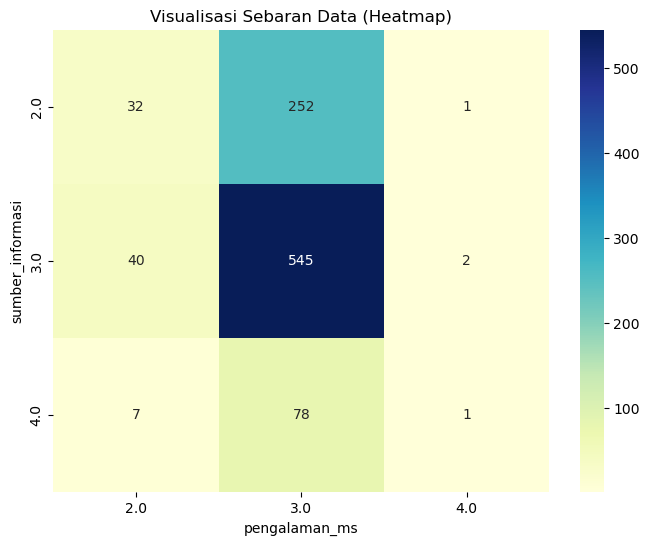

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(tabel_dukungan.iloc[:-1, :-1], annot=True, fmt='d', cmap='YlGnBu')
plt.title('Visualisasi Sebaran Data (Heatmap)')
plt.show()

In [34]:
# Membuat tabel kontingensi
# ganti 'df' dengan nama variabel DataFrame milikmu
tabel_dukungan = pd.crosstab(female_ekspor['sumber_informasi'], 
                             female_ekspor['pengalaman_ms'], 
                             margins=True) # Menambahkan total baris & kolom

print("Tabel Kontingensi: Sumber Informasi vs Pengalaman Menarche")
print(tabel_dukungan)

Tabel Kontingensi: Sumber Informasi vs Pengalaman Menarche
pengalaman_ms     2.0  3.0  4.0  All
sumber_informasi                    
2.0                32  252    1  285
3.0                40  545    2  587
4.0                 7   78    1   86
All                79  875    4  958


In [35]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# 1. Recoding Variabel Dependen (Pengalaman Menarche)
# 2.0 -> 0 (Buruk), 3.0 & 4.0 -> 1 (Baik)
female_ekspor['pengalaman_biner'] = female_ekspor['pengalaman_ms'].replace({2.0: 0, 3.0: 1, 4.0: 1})

# 2. Recoding Variabel Independen (Dukungan Sosial)
# 1.0 & 2.0 -> 0 (Kurang), 3.0 & 4.0 -> 1 (Baik)
female_ekspor['dukungan_biner'] = female_ekspor['dukungan_sosial'].replace({1.0: 0, 2.0: 0, 3.0: 1, 4.0: 1})

# 3. Recoding Variabel Independen (Sumber Informasi)
# 2.0 -> 0 (Kurang), 3.0 & 4.0 -> 1 (Baik)
female_ekspor['sumber_biner'] = female_ekspor['sumber_informasi'].replace({2.0: 0, 3.0: 1, 4.0: 1})

/tmp/ipykernel_41419/858549271.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female_ekspor['pengalaman_biner'] = female_ekspor['pengalaman_ms'].replace({2.0: 0, 3.0: 1, 4.0: 1})
/tmp/ipykernel_41419/858549271.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female_ekspor['dukungan_biner'] = female_ekspor['dukungan_sosial'].replace({1.0: 0, 2.0: 0, 3.0: 1, 4.0: 1})
/tmp/ipykernel_41419/858549271.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

In [36]:
female_ekspor

,pengalaman_ms,sumber_informasi,dukungan_sosial,pengalaman_biner,dukungan_biner,sumber_biner
0,3.0,3.0,3.0,1.0,1.0,1.0
1,3.0,3.0,3.0,1.0,1.0,1.0
2,3.0,3.0,3.0,1.0,1.0,1.0
3,3.0,3.0,3.0,1.0,1.0,1.0
4,3.0,3.0,4.0,1.0,1.0,1.0
...,...,...,...,...,...,...
953,3.0,3.0,4.0,1.0,1.0,1.0
954,3.0,3.0,3.0,1.0,1.0,1.0
955,3.0,3.0,3.0,1.0,1.0,1.0
956,3.0,3.0,3.0,1.0,1.0,1.0


In [39]:
female_ekspor.to_excel("female_final.xlsx", index=False)

In [37]:
# Membuat model logistik
# Formula: 'dependen ~ independen1 + independen2'
model = smf.logit('pengalaman_biner ~ dukungan_biner + sumber_biner', data=female_ekspor).fit()

# Menampilkan ringkasan hasil
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.259368
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       pengalaman_biner   No. Observations:                  958
Model:                          Logit   Df Residuals:                      955
Method:                           MLE   Df Model:                            2
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                 0.08912
Time:                        23:01:00   Log-Likelihood:                -248.47
converged:                       True   LL-Null:                       -272.79
Covariance Type:            nonrobust   LLR p-value:                 2.764e-11
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.2120      0.215      5.627      0.000       0.790       1.634
dukungan_biner   

In [38]:
# Menghitung Odds Ratio dan Interval Kepercayaan (95%)
model_odds = pd.DataFrame(np.exp(model.params), columns=['Odds Ratio'])
model_odds['z-value'] = model.pvalues
model_odds[['2.5%', '97.5%']] = np.exp(model.conf_int())

print("\n--- Tabel Odds Ratio ---")
print(model_odds)


--- Tabel Odds Ratio ---
                Odds Ratio       z-value      2.5%     97.5%
Intercept         3.360112  1.832964e-08  2.203026  5.124931
dukungan_biner    5.057544  3.741675e-11  3.128499  8.176046
sumber_biner      1.395046  1.829138e-01  0.854690  2.277031
